## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [7]:
data.isna().sum()

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

In [8]:
data = data.dropna().copy()

In [9]:
cat_features_mask = (data.dtypes == "object").values
cat_features_mask

array([ True,  True,  True, False, False, False, False, False,  True,
       False, False])

In [10]:
cat_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()
cat_columns

['Species', 'Island', 'Clutch Completion', 'Sex']

In [11]:
data['Clutch Completion'] = data['Clutch Completion'].map({'Yes': 1, 'No': 0})
data['Sex'] = data['Sex'].map({'MALE': 1, 'FEMALE': 0})


In [12]:
data = pd.get_dummies(data, columns=['Island'], dtype=float)
data

,Species,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen
0,Chinstrap,1,382,50.9,19.1,196.0,3550.0,1.0,10.02372,-24.86594,0.0,1.0,0.0
1,Chinstrap,1,741,45.2,17.8,198.0,3950.0,0.0,8.88942,-24.49433,0.0,1.0,0.0
2,Gentoo,1,744,46.5,13.5,210.0,4550.0,0.0,7.99530,-25.32829,1.0,0.0,0.0
3,Chinstrap,1,10,45.2,16.6,191.0,3250.0,0.0,9.62357,-24.78984,0.0,1.0,0.0
4,Gentoo,1,13,48.4,14.4,203.0,4625.0,0.0,8.16582,-26.13971,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,1,382,47.6,18.3,195.0,3850.0,0.0,8.83502,-24.65859,0.0,1.0,0.0
340,Adelie,1,382,39.7,18.4,190.0,3900.0,1.0,9.29808,-25.23453,0.0,0.0,1.0
341,Adelie,1,16,38.6,17.2,199.0,3750.0,0.0,8.77322,-26.48973,1.0,0.0,0.0
342,Gentoo,1,392,46.6,14.2,210.0,4850.0,0.0,8.38289,-26.86352,1.0,0.0,0.0


Обоснование кодировки:
К бинарным (Sex, Clutch Completion) применила просто 1/0, а не one-hot, так как он не самый оптимальный, он создает лишние столбцы без добавления новой информации.
К номинальному признаку Island применилв One-hot encoding, поскольку для него он уже будет оптимальным.

Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [13]:
from sklearn.preprocessing import OrdinalEncoder

In [14]:
data['Species'] = data['Species'].astype(str).str.strip()
target = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data[['Species']] = target.fit_transform(data[['Species']]).astype(int)



In [15]:
X = data.drop(columns=['Species'])
y = data['Species']



**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [16]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, stratify=y, random_state = 42)



In [17]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (227, 12)
X_test shape: (98, 12)
y_train shape: (227,)
y_test shape: (98,)


Обоснование почему это важно, потому что аргумент 'stratify' сохраняет примерно ту же долю классов в train и test, что и в исходных данных.
Если делить без stratify, может получиться перекос, одного класса в train будет слишком много, другого в test будет слишком мало.

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

featur = ['Flipper Length (mm)', 'Body Mass (g)']

X_train_2 = X_train[featur]
X_test_2 = X_test[featur]

standard = StandardScaler()
X_train_st = standard.fit_transform(X_train_2)
X_test_st = standard.transform(X_test_2)

neighbors = [1, 3, 5, 10, 15, 25]

clf = []
results = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_st, y_train)
    clf.append(knn)

    train_pred = knn.predict(X_train_st)
    test_pred = knn.predict(X_test_st)

    train_ac = accuracy_score(y_train, train_pred)
    test_ac = accuracy_score(y_test, test_pred)

    results.append({'k': k, 'train_accuracy': train_ac, 'test_accuracy': test_ac })

results, clf 


([{'k': 1,
   'train_accuracy': 0.973568281938326,
   'test_accuracy': 0.7551020408163265},
  {'k': 3,
   'train_accuracy': 0.8590308370044053,
   'test_accuracy': 0.7551020408163265},
  {'k': 5,
   'train_accuracy': 0.8281938325991189,
   'test_accuracy': 0.7755102040816326},
  {'k': 10,
   'train_accuracy': 0.8237885462555066,
   'test_accuracy': 0.7755102040816326},
  {'k': 15,
   'train_accuracy': 0.8149779735682819,
   'test_accuracy': 0.7551020408163265},
  {'k': 25,
   'train_accuracy': 0.7929515418502202,
   'test_accuracy': 0.8367346938775511}],
 [KNeighborsClassifier(metric='euclidean', n_neighbors=1),
  KNeighborsClassifier(metric='euclidean', n_neighbors=3),
  KNeighborsClassifier(metric='euclidean'),
  KNeighborsClassifier(metric='euclidean', n_neighbors=10),
  KNeighborsClassifier(metric='euclidean', n_neighbors=15),
  KNeighborsClassifier(metric='euclidean', n_neighbors=25)])

**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [19]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [20]:
import mlxtend 

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

In [21]:
import matplotlib.gridspec as gridspec
import itertools
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import LabelEncoder

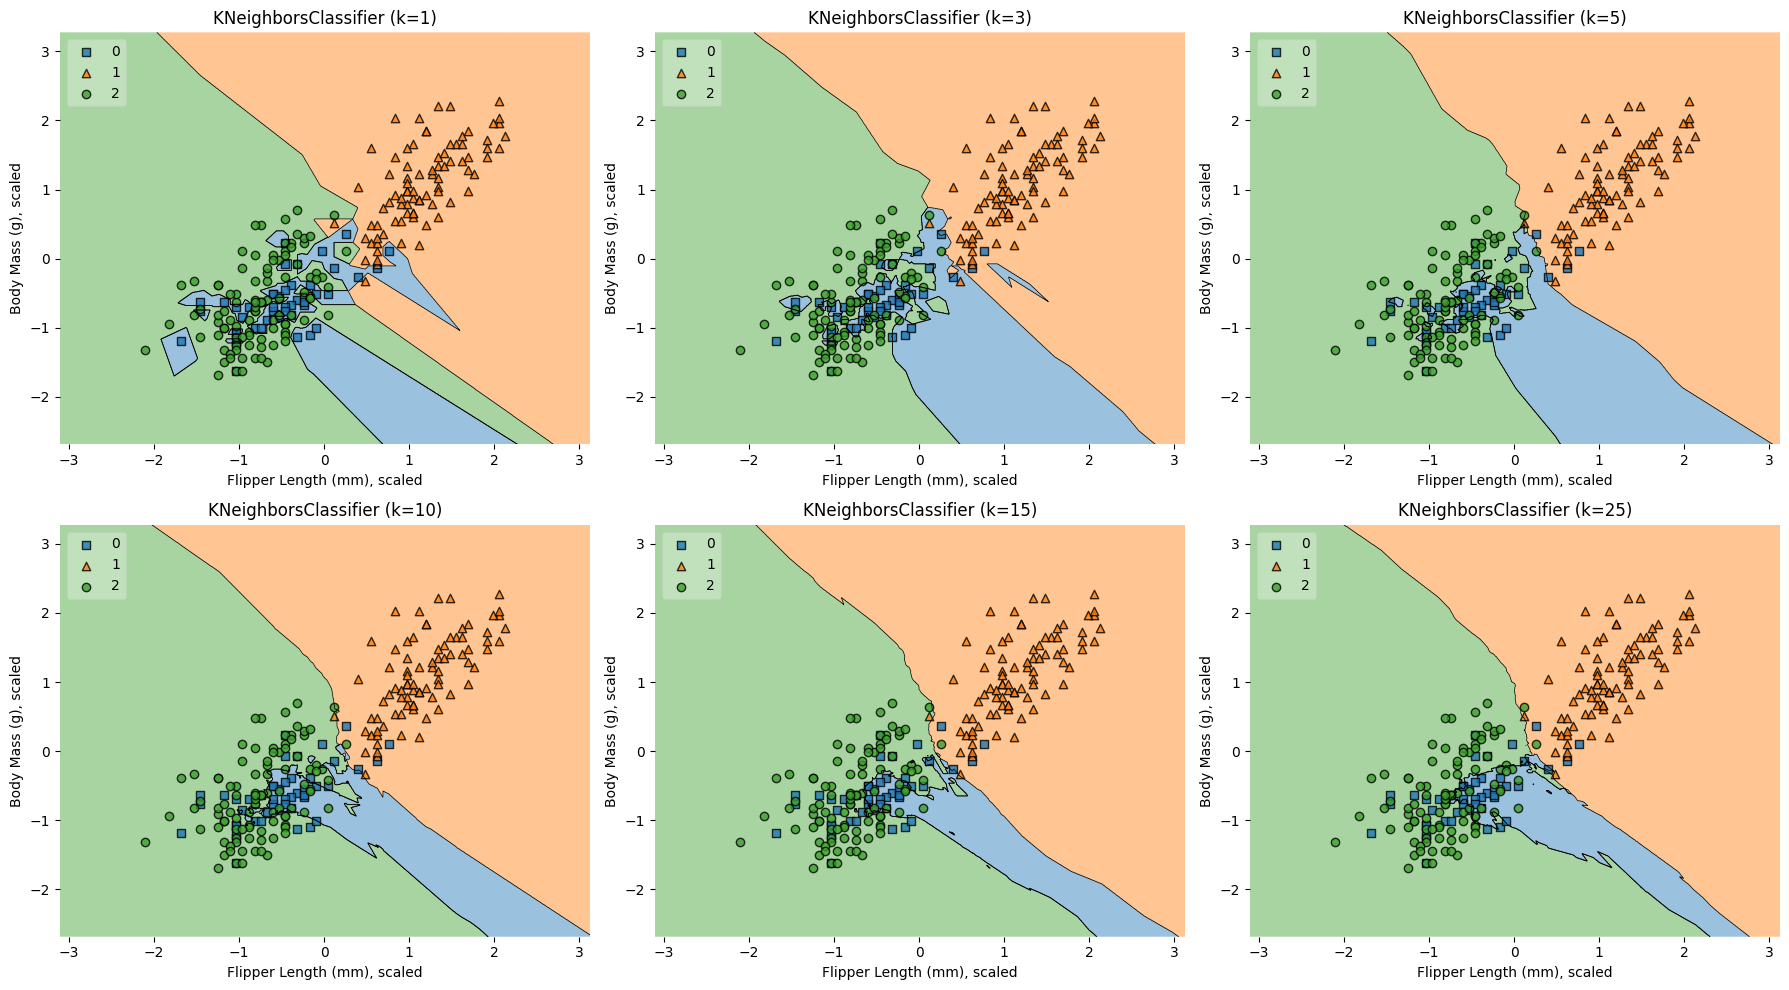

In [22]:
X_plot = np.array(X_train_st)
y_plot = np.array(y_train)


neighbors = [1, 3, 5, 10, 15, 25]

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3)

for model, k, pos in zip(clf, neighbors, itertools.product(range(2), range(3))):
    ax = plt.subplot(gs[pos[0], pos[1]])
    
    plot_decision_regions( X=X_plot, y=y_plot, clf=model, legend=2, ax=ax)
    
    ax.set_title(f'KNeighborsClassifier (k={k})')
    ax.set_xlabel('Flipper Length (mm), scaled')
    ax.set_ylabel('Body Mass (g), scaled')

plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

По результатам в 1.3 видно, что при малых k модель работает лучше на обучающей выборке, чем на тестовой. Например, при k=1 train_accuracy примерно  0.974, в то время как test_accuracy = 0.755. Это говорит о переобучении, то есть модель слишком сильно подстраивается под обучающие данные. Похожая ситуация наблюдается и при k=3.
Результаты в 1.5 показывают, что для k=1 и k=3 решающая поверхность получается слишком ломаной, с небольшими разрывами и резкими переходами между классами. Классификатор реагирует на отдельные точки, а не на общую структуру данных, то есть происходит переобучение.
При увеличении k границы становятся более гладкими. По геометрии данных видно, что один класс отделяется довольно хорошо, а два других частично пересекаются, поэтому слишком маленькое k даёт слишком сложную границу. Наиболее удачный результат получен при k=25, так как test_accuracy = 0.837, это лучше других результатов. При этом решающая поверхность выглядит наиболее сглаженной.
Таким образом, оптимально выбрать k=25, так как эта модель показывает наилучшее качество на тестовой выборке. Явное переобучение наблюдается при k=1 и чуть меньше при k=3.

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

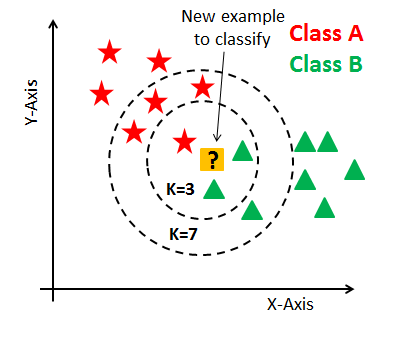

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [23]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        if not isinstance(k, int) or k <= 0:
          raise ValueError
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        if X.ndim != 2:
            raise ValueError
        if len(X) != len(y):
            raise ValueError
        if self.k > len(X):
            raise ValueError

        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        if self.X_train is None or self.y_train is None:
            raise ValueError
        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        distances = self.count_distance(X[:, None, :], self.X_train[None, :, :])

        neighbor_idx = np.argsort(distances, axis=1, kind='mergesort')[:, :self.k]

        neighbor_labels = self.y_train[neighbor_idx]

        y_pred = np.array([
            Counter(labels).most_common(1)[0][0]
            for labels in neighbor_labels
        ])

        return y_pred

    def count_distance(self, x, y):
        return np.linalg.norm(x - y, axis=-1)

In [24]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [25]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder

Решение №1

In [27]:
penguins = pd.read_csv('penguins_data.csv').copy()

obj_cols = penguins.select_dtypes(include='object').columns
for col in obj_cols:
    penguins[col] = penguins[col].astype(str).str.strip()

penguins = penguins.replace({'': np.nan, '.': np.nan})

penguins = penguins.dropna().copy()

le = LabelEncoder()
y_peng = le.fit_transform(penguins['Species'])

X_peng = pd.get_dummies(penguins.drop(columns='Species'), dtype=float)


X_train_peng, X_test_peng, y_train_peng, y_test_peng = train_test_split(
    X_peng,
    y_peng,
    test_size=0.3,
    random_state=42,
    stratify=y_peng
)

scaler = StandardScaler()
X_train_peng_scaled = scaler.fit_transform(X_train_peng)
X_test_peng_scaled = scaler.transform(X_test_peng)

nn = [1, 3, 5, 10, 15, 25]
results = []

for k in nn:
    knn = KNN(k=k)
    knn.fit(X_train_peng_scaled, y_train_peng)

    y_pred_train = knn.predict(X_train_peng_scaled)
    y_pred_test = knn.predict(X_test_peng_scaled)

    results.append({
        'k': k,
        'train_accuracy': accuracy_score(y_train_peng, y_pred_train),
        'test_accuracy': accuracy_score(y_test_peng, y_pred_test)
    })

results_df = pd.DataFrame(results)
display(results_df)

best_row = results_df.loc[results_df['test_accuracy'].idxmax()]
best_k = int(best_row['k'])
best_accuracy = float(best_row['test_accuracy'])

print(f'Лучшее k: {best_k}, accuracy на test = {best_accuracy:.4f}')


,k,train_accuracy,test_accuracy
0,1,1.000000,1.000000
1,3,0.991304,1.000000
2,5,0.982609,1.000000
3,10,0.969565,0.979798
4,15,0.969565,0.969697
5,25,0.956522,0.979798


Лучшее k: 1, accuracy на test = 1.0000


Если честно, не поняла какие признаки нужны, так что решила сделать два варианта решения: 1-ое на всех признаках и 2-0е на двух признаках, что использовала в 1.3

Лучшее качество на тестовой выборке показала модель с k = 1, значит это значение даёт наиболее удачный баланс между чувствительностью к шуму и сглаживанием границы решений. Доля правильных ответов = 1.0

Решение №2

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

features = ['Flipper Length (mm)', 'Body Mass (g)']

X_train_22 = X_train[features].copy()
X_test_22 = X_test[features].copy()
y_train_22 = y_train.copy()
y_test_22 = y_test.copy()

scaler = StandardScaler()
X_train_22_scaled = scaler.fit_transform(X_train_22)
X_test_22_scaled = scaler.transform(X_test_22)

nn = [1, 3, 5, 10, 15, 25]
results = []

for k in nn:
    knn = KNN(k=k)
    knn.fit(X_train_22_scaled, y_train_22)

    y_pred_train = knn.predict(X_train_22_scaled)
    y_pred_test = knn.predict(X_test_22_scaled)

    results.append({
        'k': k,
        'train_accuracy': accuracy_score(y_train_22, y_pred_train),
        'test_accuracy': accuracy_score(y_test_22, y_pred_test)
    })

results_df = pd.DataFrame(results)
display(results_df)

best_row = results_df.loc[results_df['test_accuracy'].idxmax()]
best_k = int(best_row['k'])
best_accuracy = float(best_row['test_accuracy'])

print(f'Лучшее k: {best_k}, accuracy на test = {best_accuracy:.4f}')


,k,train_accuracy,test_accuracy
0,1,0.969163,0.734694
1,3,0.872247,0.755102
2,5,0.828194,0.775510
3,10,0.828194,0.785714
4,15,0.810573,0.755102
5,25,0.797357,0.816327


Лучшее k: 25, accuracy на test = 0.8163


Лучшее качество на test показала модель с k = 25, это значение даёт наиболее удачный баланс между чувствительностью к шуму и сглаживанием границы решений. Доля правильных ответов = 0.8163

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [29]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [30]:
print(data.isna().sum())
print("Всего пропусков в датасете:", data.isna().sum().sum())

data = data.dropna()

if 'Unnamed: 0' in data.columns:
    data = data.drop(columns='Unnamed: 0')

data.info()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64
Всего пропусков в датасете: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


В датасете пропусков нет. Столбец Unnamed: 0 фактически бесполезный и является индексным, поэтому его удалила.

**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [31]:
num_c = data.select_dtypes(include='number').columns
corr_matrix = data[num_c].corr()

corr_with_price = corr_matrix['price'].drop('price').sort_values(key=np.abs, ascending=False)

print(corr_matrix)
print(f"Корреляции с price: {corr_with_price}.")

          carat     depth     table     price         x         y         z
carat  1.000000  0.028224  0.181618  0.921591  0.975094  0.951722  0.953387
depth  0.028224  1.000000 -0.295779 -0.010647 -0.025289 -0.029341  0.094924
table  0.181618 -0.295779  1.000000  0.127134  0.195344  0.183760  0.150929
price  0.921591 -0.010647  0.127134  1.000000  0.884435  0.865421  0.861249
x      0.975094 -0.025289  0.195344  0.884435  1.000000  0.974701  0.970772
y      0.951722 -0.029341  0.183760  0.865421  0.974701  1.000000  0.952006
z      0.953387  0.094924  0.150929  0.861249  0.970772  0.952006  1.000000
Корреляции с price: carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64.


Наибольшая корреляция с price у carat. Ещё сильная связь наблюдается у признаков x, y, z. Признак depth почти не имеет линейной связи с ценой. 
Хочу подметить, что у price с самим собой всегда корреляция будет 1, поэтому мы не берём это как наибольшую корреляцию с таргетом.

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [32]:
cat_c = data.select_dtypes(include='object').columns

data_encoded = pd.get_dummies(data, columns=cat_c, drop_first=True, dtype=int)

data_encoded.head()

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,1,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1,0,0,...,0,0,1,0,0,1,0,0,0,0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [33]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop(columns='price')
y = data_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [34]:
num_features = data.drop(columns='price').select_dtypes(include='number').columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

standar = StandardScaler()

X_train_scaled[num_features] = standar.fit_transform(X_train[num_features])
X_test_scaled[num_features] = standar.transform(X_test[num_features])

После стандартизации вещественных признаков коэффициенты линейной регрессии теряют прямую интерпретацию в исходных единицах измерения. Теперь коэффициент показывает, как изменится целевая переменная при увеличении признака на 1 стандартное отклонение, а не на 1 исходную единицу. Теперь коэффициенты разных вещественных признаков становятся сопоставимыми между собой по масштабу.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("Train MSE:", mse_train)
print("Test MSE:", mse_test)

Train MSE: 1290541.9147450614
Test MSE: 1244765.4357158681


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [36]:
coef_lr = pd.Series(lr.coef_, index=X_train_scaled.columns)
coef_lr_sorted = coef_lr.sort_values(key=np.abs, ascending=False)

print(coef_lr_sorted)
print("Вещественные признаки:")
print(coef_lr[num_features].sort_values(key=np.abs, ascending=False))


clarity_IF       5459.037300
carat            5338.615671
clarity_VVS1     5101.335181
clarity_VVS2     5028.295530
clarity_VS1      4657.834307
clarity_VS2      4336.725583
clarity_SI1      3751.709671
clarity_SI2      2781.940548
color_J         -2381.989788
color_I         -1476.084233
x               -1100.418850
color_H          -998.634669
cut_Ideal         846.196258
cut_Premium       777.769963
cut_Very Good     743.301360
cut_Good          595.521080
color_G          -500.160238
color_F          -273.303976
color_E          -217.028968
depth             -90.173817
table             -60.332280
z                 -34.258945
y                  -6.458917
dtype: float64
Вещественные признаки:
carat    5338.615671
x       -1100.418850
depth     -90.173817
table     -60.332280
z         -34.258945
y          -6.458917
dtype: float64


Среди вещественных признаков наибольшие по модулю коэффициенты у "carat" и "x", причём особенно выделяется carat. После стандартизации именно эти числовые признаки сильнее остальных связаны с изменением цены в линейной модели.

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [37]:
from sklearn.linear_model import Lasso, Ridge

las = Lasso(alpha=10, max_iter=100000)
rid = Ridge(alpha=10)

las.fit(X_train_scaled, y_train)
rid.fit(X_train_scaled, y_train)

coef_lasso_10 = pd.Series(las.coef_, index=X_train_scaled.columns)
coef_ridge_10 = pd.Series(rid.coef_, index=X_train_scaled.columns)

print("||w||   =", np.linalg.norm(lr.coef_))
print("||w_Lasso|| =", np.linalg.norm(coef_lasso_10))
print("||w_Ridge|| =", np.linalg.norm(coef_ridge_10))

||w||   = 13586.771615191663
||w_Lasso|| = 5822.638888104583
||w_Ridge|| = 12262.96033884276


Вывод: 
Lasso уменьшила норму коэффициентов сильнее, чем Ridge. Это согласуется с предположением о наличии мультиколлинеарности и показывает, что регуляризация делает модель устойчивее, но по одной только норме коэффициентов нельзя строго количественно оценить силу мультиколлинеарности.

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

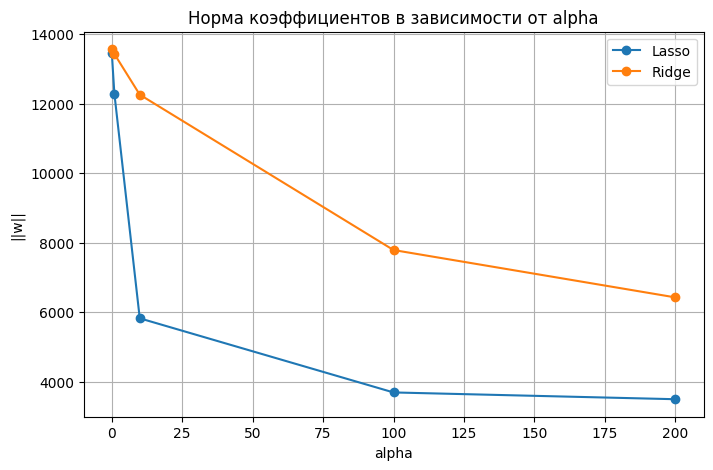

In [38]:
alphas = [0.1, 1, 10, 100, 200]

lasso_norms = []
ridge_norms = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=100000)
    ridge = Ridge(alpha=alpha)

    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    lasso_norms.append(np.linalg.norm(lasso.coef_))
    ridge_norms.append(np.linalg.norm(ridge.coef_))

plt.figure(figsize=(8, 5))
plt.plot(alphas, lasso_norms, marker='o', label='Lasso')
plt.plot(alphas, ridge_norms, marker='o', label='Ridge')
plt.xlabel('alpha')
plt.ylabel('||w||')
plt.title('Норма коэффициентов в зависимости от alpha')
plt.legend()
plt.grid(True)
plt.show()

Lasso уменьшает норму коэффициентов сильнее, чем Ridge. Это связано с L1-регуляризацией, которая сильнее сжимает веса и может даже занулять некоторые, поэтому Lasso используют для отбора признаков.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [39]:
from sklearn.linear_model import LassoCV

alphas_grid = np.logspace(-3, 2, 100)

lasso_cv = LassoCV(alphas=alphas_grid, cv=5, random_state=42, max_iter=100000)

lasso_cv.fit(X_train_scaled, y_train)

mean_cv_mse = lasso_cv.mse_path_.mean(axis=1)
best_alpha = lasso_cv.alphas_[np.argmin(mean_cv_mse)]

print("Лучшая alpha по среднему CV-MSE:", best_alpha)
print("alpha из модели:", lasso_cv.alpha_)

Лучшая alpha по среднему CV-MSE: 0.37649358067924676
alpha из модели: 0.37649358067924676


По 5 фолд кросс-валидации оптимальное значение alpha выбирается как то, для которого средняя MSE минимальна. В этом примере самая оптимальная alpha получается примерно 0.3765.

**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [40]:
best_alpha = lasso_cv.alpha_

lasso_final = Lasso(alpha=best_alpha, max_iter=100000)
lasso_final.fit(X_train_scaled, y_train)

coef_lasso_final = pd.Series(lasso_final.coef_, index=X_train_scaled.columns).sort_values(key=np.abs, ascending=False)

coef_lasso_final

carat            5315.304015
clarity_IF       5246.267538
clarity_VVS1     4895.896478
clarity_VVS2     4825.547423
clarity_VS1      4456.479851
clarity_VS2      4138.352852
clarity_SI1      3554.532206
clarity_SI2      2586.407960
color_J         -2351.263024
color_I         -1449.542376
x               -1086.846549
color_H          -975.872966
cut_Ideal         808.322116
cut_Premium       739.602810
cut_Very Good     707.200147
cut_Good          556.499407
color_G          -478.065734
color_F          -253.117172
color_E          -196.819687
depth             -93.558723
table             -62.779288
z                 -33.080001
y                  -3.255601
dtype: float64

Самые информативные признаки это carat, а также признаки, связанные с clarity и color. Признаки, наименьшие по модулю это y, z, table, depth, так как их вклад в модель слабый или немного дублирует другие признаки. Нельзя сказать, что они совсем неинформативны, потому что они не занулили коэффициенты в lasso.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [41]:
y_test_pred_lasso = lasso_final.predict(X_test_scaled)
mse_lasso_test = mean_squared_error(y_test, y_test_pred_lasso)

print("Test MSE обычной лин.регрессии:", mse_test)
print("Test MSE Lasso-регрессии:", mse_lasso_test)

Test MSE обычной лин.регрессии: 1244765.4357158681
Test MSE Lasso-регрессии: 1243661.3446265818


Lasso-регрессия показала немного меньшую MSE на тестовой выборке, чем обычная линейная регрессия, но разница невелика. Значит, регуляризация слегка улучшила обобщающую способность модели, вероятно за счёт более устойчивых коэффициентов при наличии коррелированных признаков.